In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
import os
import pandas as pd

if os.path.exists("cleaned_online_retail.csv"):
    clean_df = pd.read_csv("cleaned_online_retail.csv")
    clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])
    print("Cleaned dataset loaded successfully.")
else:
    print("cleaned_online_retail.csv not found.")

Cleaned dataset loaded successfully.


In [4]:
print("Dataset shape:", clean_df.shape)
print("\nColumns:")
print(clean_df.columns.tolist())

print("\nDate range:")
print(clean_df["InvoiceDate"].min(), "to", clean_df["InvoiceDate"].max())

print("\nUnique customers:", clean_df["CustomerID"].nunique())

Dataset shape: (164215, 13)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Year', 'Month', 'Day', 'Hour']

Date range:
2010-12-01 08:26:00 to 2011-06-22 15:07:00

Unique customers: 2912


In [5]:
cutoff_date = pd.Timestamp("2011-09-01")

historical_df = clean_df[clean_df["InvoiceDate"] < cutoff_date].copy()
future_df = clean_df[clean_df["InvoiceDate"] >= cutoff_date].copy()

print("Historical period:")
print(historical_df["InvoiceDate"].min(), "to", historical_df["InvoiceDate"].max())

print("\nFuture period:")
print(future_df["InvoiceDate"].min(), "to", future_df["InvoiceDate"].max())

print("\nHistorical transactions:", len(historical_df))
print("Future transactions:", len(future_df))

Historical period:
2010-12-01 08:26:00 to 2011-06-22 15:07:00

Future period:
NaT to NaT

Historical transactions: 164214
Future transactions: 0


In [6]:
historical_customers = historical_df["CustomerID"].unique()

future_customers = set(future_df["CustomerID"].unique())

target_df = pd.DataFrame({
    "CustomerID": historical_customers
})

target_df["RepeatPurchase"] = target_df["CustomerID"].isin(
    future_customers
).astype(int)

print(target_df.head())

print("\nTarget distribution:")
print(target_df["RepeatPurchase"].value_counts())

print("\nTarget percentage:")
print(
    target_df["RepeatPurchase"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

   CustomerID  RepeatPurchase
0     17850.0               0
1     13047.0               0
2     12583.0               0
3     13748.0               0
4     15100.0               0

Target distribution:
RepeatPurchase
0    2912
Name: count, dtype: int64

Target percentage:
RepeatPurchase
0    100.0
Name: proportion, dtype: float64


In [13]:
print("Historical transactions:", len(historical_df))
print("Future transactions:", len(future_df))

print("\nHistorical date range:")
print(historical_df["InvoiceDate"].min(), "to", historical_df["InvoiceDate"].max())

print("\nFuture date range:")
print(future_df["InvoiceDate"].min(), "to", future_df["InvoiceDate"].max())

print("\nHistorical customers:", historical_df["CustomerID"].nunique())
print("Future customers:", future_df["CustomerID"].nunique())

print("\nFirst 10 future CustomerIDs:")
print(future_df["CustomerID"].dropna().unique()[:10])

Historical transactions: 164214
Future transactions: 0

Historical date range:
2010-12-01 08:26:00 to 2011-06-22 15:07:00

Future date range:
NaT to NaT

Historical customers: 2912
Future customers: 0

First 10 future CustomerIDs:
[]


In [14]:
historical_customer_set = set(
    historical_df["CustomerID"].dropna().unique()
)

future_customer_set = set(
    future_df["CustomerID"].dropna().unique()
)

repeat_customers = historical_customer_set.intersection(
    future_customer_set
)

print("Customers in historical period:", len(historical_customer_set))
print("Customers in future period:", len(future_customer_set))
print("Customers appearing in BOTH periods:", len(repeat_customers))

Customers in historical period: 2912
Customers in future period: 0
Customers appearing in BOTH periods: 0


In [15]:
print("Dataset shape:", clean_df.shape)

print("\nDate range:")
print(clean_df["InvoiceDate"].min())
print(clean_df["InvoiceDate"].max())

print("\nLast 10 dates:")
print(clean_df["InvoiceDate"].sort_values().tail(10).to_list())

Dataset shape: (164215, 13)

Date range:
2010-12-01 08:26:00
2011-06-22 15:07:00

Last 10 dates:
[Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), Timestamp('2011-06-22 15:07:00'), NaT]


In [16]:
import os

print("File size:", os.path.getsize("cleaned_online_retail.csv") / (1024 * 1024), "MB")

File size: 40.78063774108887 MB


In [19]:
# Load original Online Retail dataset
df = pd.read_csv("/content/Online Retail.csv", encoding="latin1")

print("Original dataset shape:", df.shape)
print("Original date range:")
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

Original dataset shape: (541909, 8)
Original date range:
01-02-2011 08:23 to 31-10-2011 17:19


In [20]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    dayfirst=True,
    errors="coerce"
)

print("Converted date range:")
print(
    df["InvoiceDate"].min(),
    "to",
    df["InvoiceDate"].max()
)

print("\nMissing InvoiceDate values:")
print(df["InvoiceDate"].isna().sum())

Converted date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00

Missing InvoiceDate values:
0


In [21]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("InvoiceDate dtype:", df["InvoiceDate"].dtype)

Dataset shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
InvoiceDate dtype: datetime64[ns]


In [22]:
clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Remove rows with missing Description or CustomerID
clean_df = clean_df.dropna(subset=["Description"])
clean_df = clean_df.dropna(subset=["CustomerID"])

# Remove cancellation invoices
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only positive quantities and prices
clean_df = clean_df[clean_df["Quantity"] > 0]
clean_df = clean_df[clean_df["UnitPrice"] > 0]

# Convert CustomerID to integer
clean_df["CustomerID"] = clean_df["CustomerID"].astype(int)

# Create transaction amount
clean_df["TotalAmount"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

# Create date-related features
clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.month
clean_df["Day"] = clean_df["InvoiceDate"].dt.day
clean_df["Hour"] = clean_df["InvoiceDate"].dt.hour

print("Cleaned dataset shape:", clean_df.shape)

print("\nDate range:")
print(
    clean_df["InvoiceDate"].min(),
    "to",
    clean_df["InvoiceDate"].max()
)

print("\nUnique customers:", clean_df["CustomerID"].nunique())

Cleaned dataset shape: (392692, 13)

Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00

Unique customers: 4338


In [23]:
print("Missing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:", clean_df.duplicated().sum())

print("\nMinimum Quantity:", clean_df["Quantity"].min())
print("Minimum UnitPrice:", clean_df["UnitPrice"].min())

print("\nCancellation invoices:",
      clean_df["InvoiceNo"].astype(str).str.startswith("C").sum())

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
Year           0
Month          0
Day            0
Hour           0
dtype: int64

Duplicate rows: 0

Minimum Quantity: 1
Minimum UnitPrice: 0.001

Cancellation invoices: 0


In [24]:
cutoff_date = pd.Timestamp("2011-09-01")

historical_df = clean_df[
    clean_df["InvoiceDate"] < cutoff_date
].copy()

future_df = clean_df[
    clean_df["InvoiceDate"] >= cutoff_date
].copy()

print("Historical transactions:", len(historical_df))
print("Future transactions:", len(future_df))

print("\nHistorical date range:")
print(
    historical_df["InvoiceDate"].min(),
    "to",
    historical_df["InvoiceDate"].max()
)

print("\nFuture date range:")
print(
    future_df["InvoiceDate"].min(),
    "to",
    future_df["InvoiceDate"].max()
)

print("\nHistorical customers:",
      historical_df["CustomerID"].nunique())

print("Future customers:",
      future_df["CustomerID"].nunique())

Historical transactions: 224036
Future transactions: 168656

Historical date range:
2010-12-01 08:26:00 to 2011-08-31 17:16:00

Future date range:
2011-09-01 08:25:00 to 2011-12-09 12:50:00

Historical customers: 3317
Future customers: 2973


In [25]:
historical_customers = set(
    historical_df["CustomerID"].unique()
)

future_customers = set(
    future_df["CustomerID"].unique()
)

repeat_customers = historical_customers.intersection(
    future_customers
)

target_df = pd.DataFrame({
    "CustomerID": list(historical_customers)
})

target_df["RepeatPurchase"] = (
    target_df["CustomerID"]
    .isin(future_customers)
    .astype(int)
)

print("Customers in both periods:", len(repeat_customers))

print("\nTarget distribution:")
print(target_df["RepeatPurchase"].value_counts())

print("\nTarget percentage:")
print(
    target_df["RepeatPurchase"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Customers in both periods: 1952

Target distribution:
RepeatPurchase
1    1952
0    1365
Name: count, dtype: int64

Target percentage:
RepeatPurchase
1    58.85
0    41.15
Name: proportion, dtype: float64


In [26]:
reference_date = historical_df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_features = historical_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
).reset_index()

customer_features["AvgOrderValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

print("Customer feature dataset shape:", customer_features.shape)

display(customer_features.head())

Customer feature dataset shape: (3317, 7)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue
0,12346,226,1,77183.60,74215,1,77183.600000
1,12347,30,5,2790.86,1590,82,558.172000
2,12348,149,3,1487.24,2124,22,495.746667
3,12350,211,1,334.40,197,17,334.400000
4,12352,163,5,1561.81,254,26,312.362000


In [27]:
model_df = customer_features.merge(
    target_df,
    on="CustomerID",
    how="inner"
)

print("Final modeling dataset shape:", model_df.shape)

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nTarget distribution:")
print(model_df["RepeatPurchase"].value_counts())

print("\nTarget percentage:")
print(
    model_df["RepeatPurchase"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final modeling dataset shape: (3317, 8)

Missing values:
CustomerID        0
Recency           0
Frequency         0
Monetary          0
TotalQuantity     0
UniqueProducts    0
AvgOrderValue     0
RepeatPurchase    0
dtype: int64

Target distribution:
RepeatPurchase
1    1952
0    1365
Name: count, dtype: int64

Target percentage:
RepeatPurchase
1    58.85
0    41.15
Name: proportion, dtype: float64


In [28]:
print(model_df.describe().round(2))

       CustomerID  Recency  Frequency   Monetary  TotalQuantity  \
count     3317.00  3317.00    3317.00    3317.00        3317.00   
mean     15284.20    93.11       3.44    1575.97         923.76   
std       1724.18    76.68       5.59    5974.01        3733.91   
min      12346.00     1.00       1.00       2.90           1.00   
25%      13799.00    28.00       1.00     258.25         128.00   
50%      15245.00    73.00       2.00     552.80         305.00   
75%      16770.00   146.00       4.00    1355.11         767.00   
max      18287.00   274.00     127.00  176355.94      126731.00   

       UniqueProducts  AvgOrderValue  RepeatPurchase  
count         3317.00        3317.00         3317.00  
mean            49.09         399.43            0.59  
std             66.19        1435.70            0.49  
min              1.00           2.90            0.00  
25%             13.00         168.20            0.00  
50%             29.00         283.50            1.00  
75%        

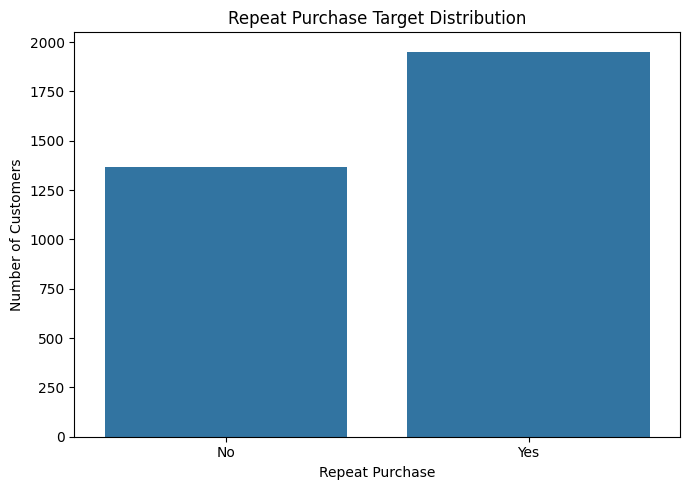

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=model_df,
    x="RepeatPurchase"
)

plt.title("Repeat Purchase Target Distribution")
plt.xlabel("Repeat Purchase")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No", "Yes"])

plt.tight_layout()
plt.show()

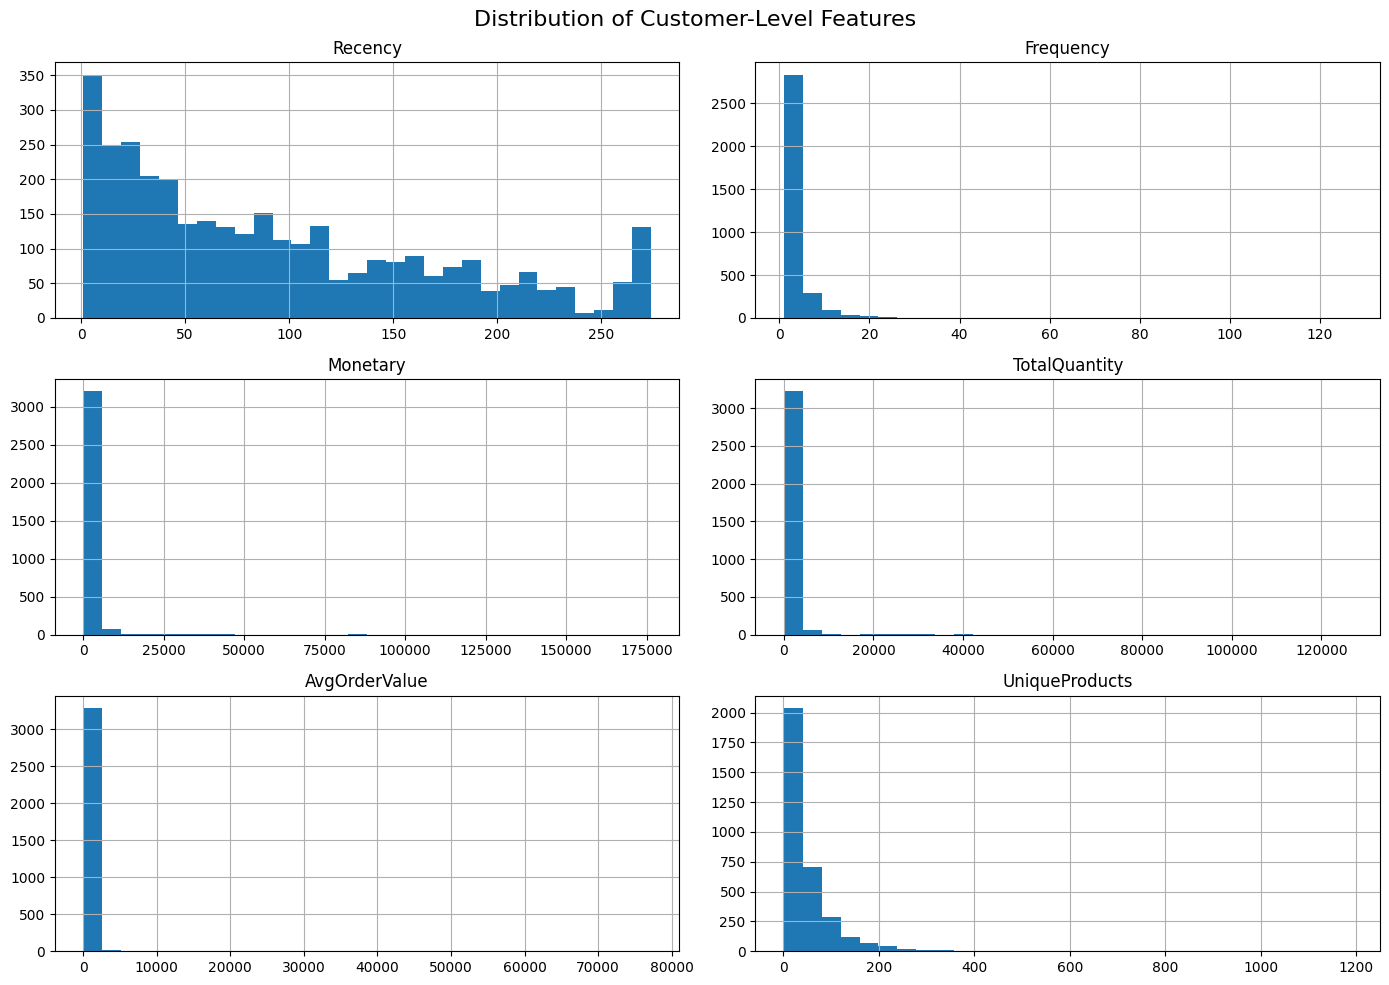

In [30]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AvgOrderValue",
    "UniqueProducts"
]

model_df[feature_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle(
    "Distribution of Customer-Level Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

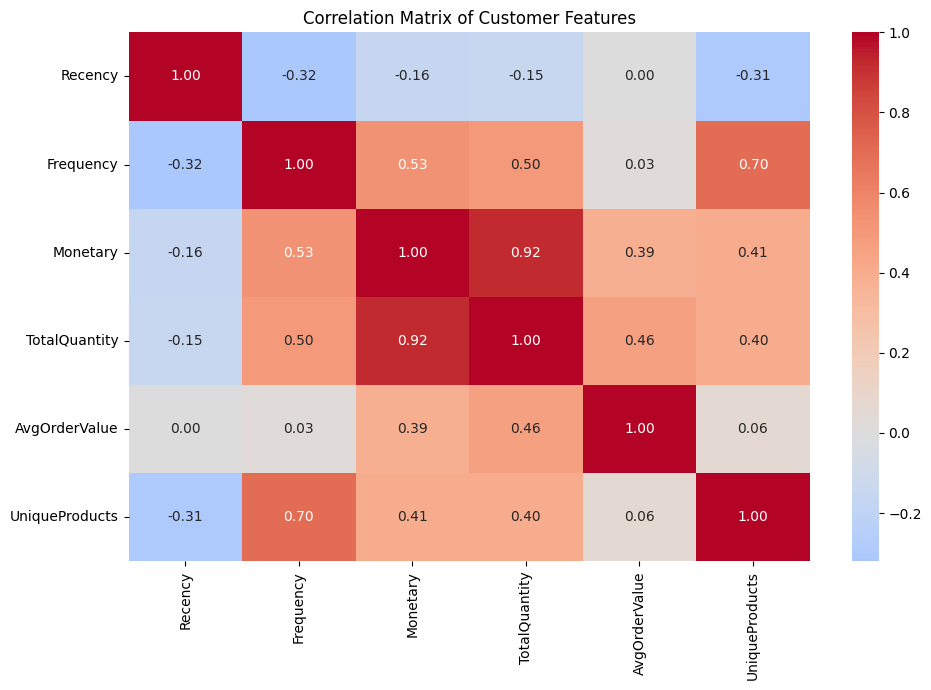

In [31]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    model_df[feature_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Customer Features")
plt.tight_layout()
plt.show()

In [32]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AvgOrderValue"
]

X = model_df[feature_columns]
y = model_df["RepeatPurchase"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Feature matrix shape: (3317, 6)
Target shape: (3317,)

Target distribution:
RepeatPurchase
1    1952
0    1365
Name: count, dtype: int64

Target percentage:
RepeatPurchase
1    58.85
0    41.15
Name: proportion, dtype: float64


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (2653, 6)
Testing set shape: (664, 6)

Training target distribution:
RepeatPurchase
1    1561
0    1092
Name: count, dtype: int64

Testing target distribution:
RepeatPurchase
1    391
0    273
Name: count, dtype: int64


In [34]:
from sklearn.preprocessing import FunctionTransformer

log_scaler = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

X_train_processed = log_scaler.fit_transform(X_train)
X_test_processed = log_scaler.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nProcessed training mean:")
print(np.round(X_train_processed.mean(axis=0), 4))

print("\nProcessed training standard deviation:")
print(np.round(X_train_processed.std(axis=0), 4))

Processed training shape: (2653, 6)
Processed testing shape: (664, 6)

Processed training mean:
[ 0.  0. -0. -0.  0.  0.]

Processed training standard deviation:
[1. 1. 1. 1. 1. 1.]


In [35]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_processed, y_train)

y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression model trained successfully.")
print("Predictions generated:", len(y_pred_lr))

Logistic Regression model trained successfully.
Predictions generated: 664


In [36]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
----------------------------------------
Accuracy : 0.6852
Precision: 0.7395
Recall   : 0.7187
F1-Score : 0.7289
ROC-AUC  : 0.7344

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.64      0.62       273
           1       0.74      0.72      0.73       391

    accuracy                           0.69       664
   macro avg       0.68      0.68      0.68       664
weighted avg       0.69      0.69      0.69       664



Logistic Regression Confusion Matrix:
[[174  99]
 [110 281]]


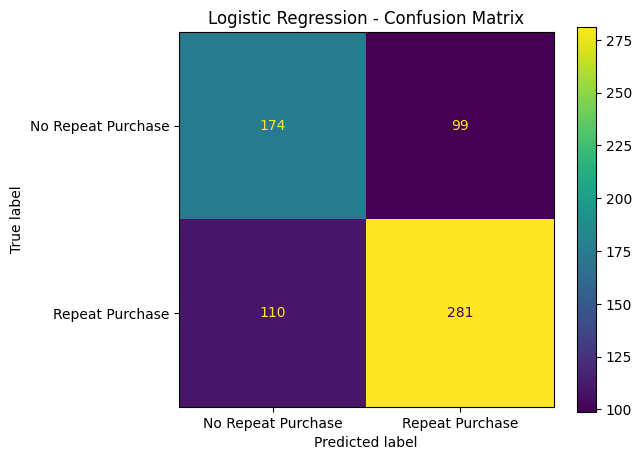

In [37]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Repeat Purchase", "Repeat Purchase"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [38]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv_accuracy = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="accuracy"
)

lr_cv_f1 = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1"
)

lr_cv_roc_auc = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression - 5-Fold Cross-Validation")
print("-" * 50)

print("Accuracy scores:", np.round(lr_cv_accuracy, 4))
print("Mean Accuracy:", round(lr_cv_accuracy.mean(), 4))

print("\nF1 scores:", np.round(lr_cv_f1, 4))
print("Mean F1:", round(lr_cv_f1.mean(), 4))

print("\nROC-AUC scores:", np.round(lr_cv_roc_auc, 4))
print("Mean ROC-AUC:", round(lr_cv_roc_auc.mean(), 4))
print("ROC-AUC Std:", round(lr_cv_roc_auc.std(), 4))

Logistic Regression - 5-Fold Cross-Validation
--------------------------------------------------
Accuracy scores: [0.6798 0.6968 0.6685 0.7094 0.6491]
Mean Accuracy: 0.6807

F1 scores: [0.7344 0.7488 0.717  0.7475 0.6951]
Mean F1: 0.7286

ROC-AUC scores: [0.7455 0.761  0.7356 0.7629 0.7186]
Mean ROC-AUC: 0.7447
ROC-AUC Std: 0.0165


In [39]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

y_pred_rf = random_forest_model.predict(X_test_processed)
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest model trained successfully.")
print("Predictions generated:", len(y_pred_rf))


Random Forest model trained successfully.
Predictions generated: 664


In [40]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
----------------------------------------
Accuracy : 0.6386
Precision: 0.6931
Recall   : 0.6931
F1-Score : 0.6931
ROC-AUC  : 0.7001

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       273
           1       0.69      0.69      0.69       391

    accuracy                           0.64       664
   macro avg       0.63      0.63      0.63       664
weighted avg       0.64      0.64      0.64       664



Random Forest Confusion Matrix:
[[153 120]
 [120 271]]


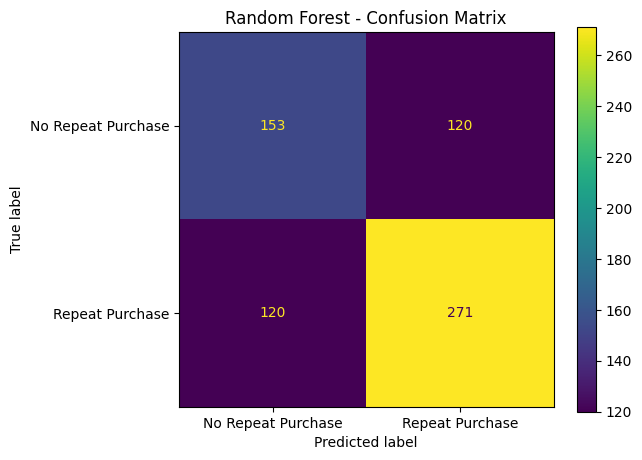

In [41]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Repeat Purchase", "Repeat Purchase"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [42]:
rf_cv_accuracy = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="accuracy"
)

rf_cv_f1 = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="f1"
)

rf_cv_roc_auc = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest - 5-Fold Cross-Validation")
print("-" * 50)

print("Accuracy scores:", np.round(rf_cv_accuracy, 4))
print("Mean Accuracy:", round(rf_cv_accuracy.mean(), 4))

print("\nF1 scores:", np.round(rf_cv_f1, 4))
print("Mean F1:", round(rf_cv_f1.mean(), 4))

print("\nROC-AUC scores:", np.round(rf_cv_roc_auc, 4))
print("Mean ROC-AUC:", round(rf_cv_roc_auc.mean(), 4))

print("ROC-AUC Std:", round(rf_cv_roc_auc.std(), 4))

Random Forest - 5-Fold Cross-Validation
--------------------------------------------------
Accuracy scores: [0.6591 0.6535 0.661  0.6585 0.6283]
Mean Accuracy: 0.6521

F1 scores: [0.7122 0.7134 0.7179 0.7141 0.6765]
Mean F1: 0.7068

ROC-AUC scores: [0.7277 0.7329 0.7072 0.722  0.6977]
Mean ROC-AUC: 0.7175
ROC-AUC Std: 0.0131


<Figure size 900x700 with 0 Axes>

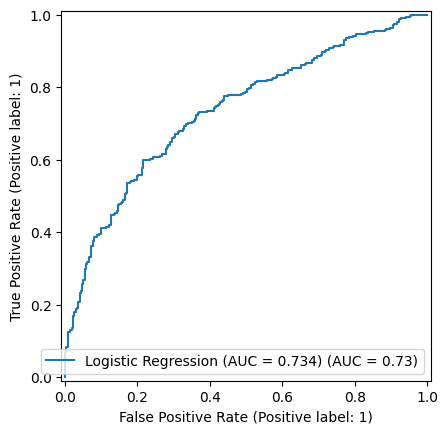

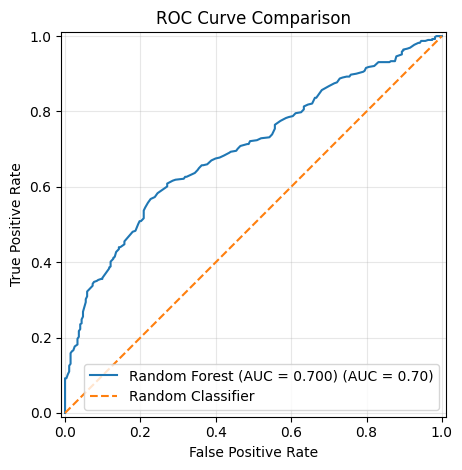

In [43]:
plt.figure(figsize=(9, 7))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
print(feature_importance.to_string(index=False))

Random Forest Feature Importance:
       Feature  Importance
      Monetary    0.201359
 TotalQuantity    0.198308
       Recency    0.193191
 AvgOrderValue    0.165496
UniqueProducts    0.161418
     Frequency    0.080227


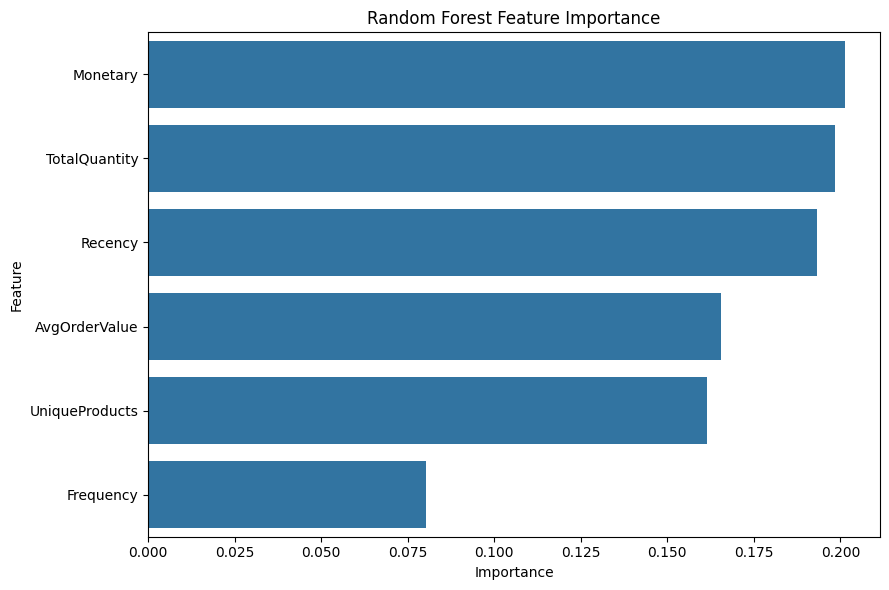

In [45]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [46]:
lr_coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": logistic_model.coef_[0]
})

lr_coefficients["Abs_Coefficient"] = (
    lr_coefficients["Coefficient"].abs()
)

lr_coefficients = lr_coefficients.sort_values(
    "Abs_Coefficient",
    ascending=False
)

print("Logistic Regression Coefficients:")
print(
    lr_coefficients[
        ["Feature", "Coefficient"]
    ].to_string(index=False)
)

Logistic Regression Coefficients:
       Feature  Coefficient
     Frequency     1.214338
      Monetary    -0.802823
 AvgOrderValue     0.436766
UniqueProducts     0.287357
       Recency    -0.279137
 TotalQuantity     0.191719


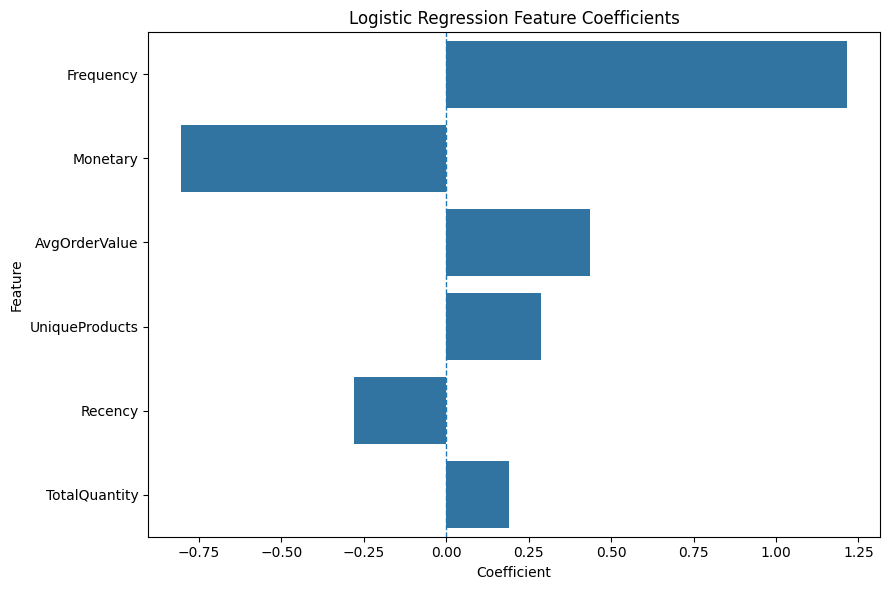

In [47]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=lr_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [48]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Test Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Test Precision": [
        lr_precision,
        rf_precision
    ],
    "Test Recall": [
        lr_recall,
        rf_recall
    ],
    "Test F1": [
        lr_f1,
        rf_f1
    ],
    "Test ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ],
    "CV Accuracy": [
        lr_cv_accuracy.mean(),
        rf_cv_accuracy.mean()
    ],
    "CV F1": [
        lr_cv_f1.mean(),
        rf_cv_f1.mean()
    ],
    "CV ROC-AUC": [
        lr_cv_roc_auc.mean(),
        rf_cv_roc_auc.mean()
    ]
})

print(
    model_comparison.round(4).to_string(index=False)
)

              Model  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC  CV Accuracy  CV F1  CV ROC-AUC
Logistic Regression         0.6852          0.7395       0.7187   0.7289        0.7344       0.6807 0.7286      0.7447
      Random Forest         0.6386          0.6931       0.6931   0.6931        0.7001       0.6521 0.7068      0.7175


In [49]:
predictions_df = model_df.loc[
    X_test.index,
    ["CustomerID", "RepeatPurchase"]
].copy()

predictions_df["Predicted_RepeatPurchase"] = y_pred_lr
predictions_df["RepeatPurchase_Probability"] = y_prob_lr

predictions_df.to_csv(
    "task4_customer_repeat_purchase_predictions.csv",
    index=False
)

print("Prediction file saved successfully.")
print("Shape:", predictions_df.shape)
print("\nPreview:")
print(predictions_df.head())

Prediction file saved successfully.
Shape: (664, 4)

Preview:
      CustomerID  RepeatPurchase  Predicted_RepeatPurchase  \
2638       17053               0                         0   
1995       15864               1                         0   
820        13780               1                         0   
2205       16250               0                         0   
2542       16872               1                         1   

      RepeatPurchase_Probability  
2638                    0.444647  
1995                    0.469907  
820                     0.414198  
2205                    0.495020  
2542                    0.600459  


In [50]:
from google.colab import files

files.download(
    "task4_customer_repeat_purchase_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

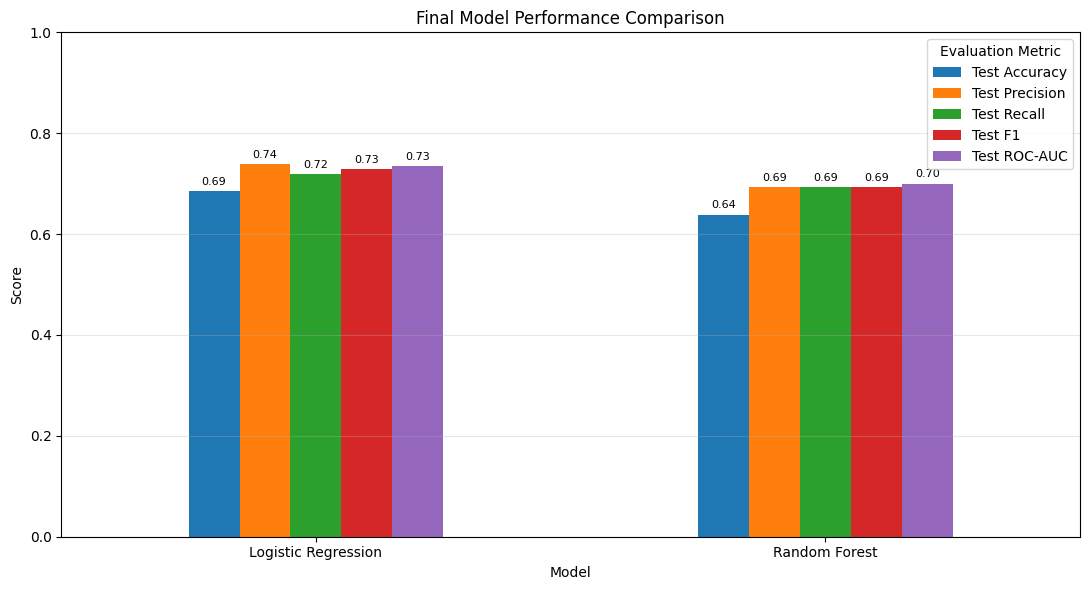

In [51]:
comparison_plot = model_comparison.set_index("Model")[
    [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC"
    ]
]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

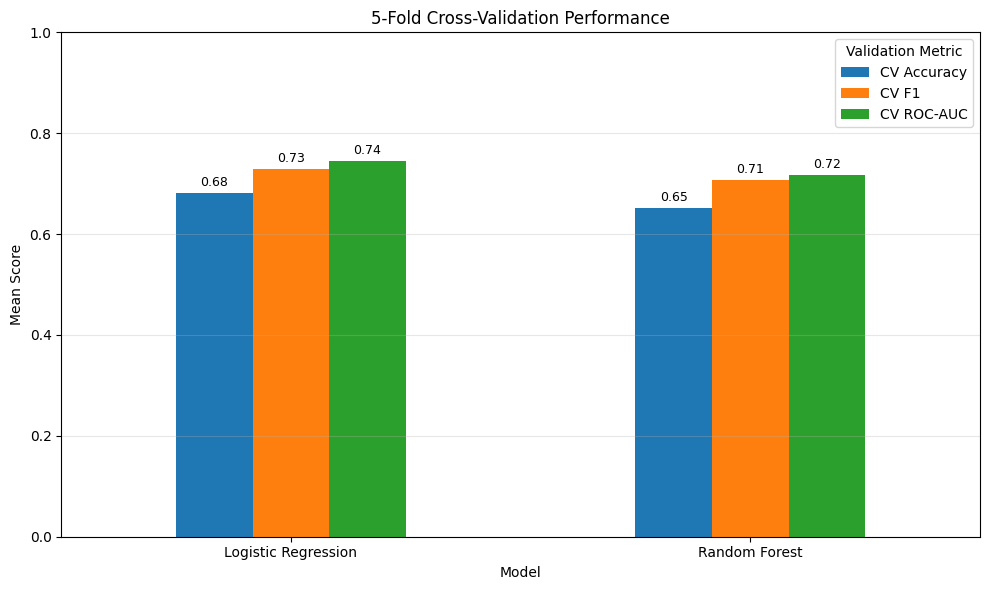

In [52]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "CV Accuracy": [
        lr_cv_accuracy.mean(),
        rf_cv_accuracy.mean()
    ],
    "CV F1": [
        lr_cv_f1.mean(),
        rf_cv_f1.mean()
    ],
    "CV ROC-AUC": [
        lr_cv_roc_auc.mean(),
        rf_cv_roc_auc.mean()
    ]
}).set_index("Model")

ax = cv_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Validation Metric")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()